Cargamos las librerias

In [40]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder
import openpyxl

Cargamos el excel

In [41]:
df_total=pd.read_excel("Data/Prestamos_Data_Alumnos_v5.xlsx", engine = "openpyxl")
df_total.head()

,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Estudios,Tipo_Jornada_Laboral,Estado_Civil,Posesion_Hipoteca,Personas_Cargo,Proposito,Fiador,Impago,Prima
0,O77MPJ,26,19153.0,6973,706,9.0,1,19.05,36.0,0.10,Grado Universitario,Jornada completa,Soltero,0.0,1.0,Automóvil,1.0,1,130.83
1,6B4H6E,22,16000.0,10000,769,22.0,1,8.96,48.0,0.32,Escolar,Desempleado,Soltero,1.0,1.0,Vivienda,0.0,0,65.85
2,VKTUXP,33,38308.0,16474,699,70.0,3,14.07,36.0,0.20,Máster,Jornada completa,Casado,1.0,1.0,Vivienda,0.0,0,260.60
3,5P9OVL,51,51271.0,40770,812,309.0,1,12.66,12.0,0.36,Grado Universitario,Jornada completa,Casado,0.0,1.0,Vivienda,1.0,0,221.02
4,KG9CT9,34,56572.0,73978,763,86.0,1,13.91,60.0,0.55,Máster,Tiempo parcial,Soltero,0.0,0.0,Educación,0.0,0,800.00


Vemos a ver como esta distribuida la columna proposito para filtrar

In [42]:
df_total["Proposito"].value_counts()

Proposito
Educación    178609
Vivienda     101899
Automóvil     76930
Otros         76748
Negocios      76515
Name: count, dtype: int64

Filtramos por nuestro tipo de crédito: _`Vivienda`_

In [43]:
df_filtrado = df_total[df_total["Proposito"]== "Vivienda"]

Vemos el dataframe

In [44]:
df_filtrado

,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Estudios,Tipo_Jornada_Laboral,Estado_Civil,Posesion_Hipoteca,Personas_Cargo,Proposito,Fiador,Impago,Prima
1,6B4H6E,22,16000.0,10000,769,22.0,1,8.96,48.0,0.32,Escolar,Desempleado,Soltero,1.0,1.0,Vivienda,0.0,0,65.85
2,VKTUXP,33,38308.0,16474,699,70.0,3,14.07,36.0,0.20,Máster,Jornada completa,Casado,1.0,1.0,Vivienda,0.0,0,260.60
3,5P9OVL,51,51271.0,40770,812,309.0,1,12.66,12.0,0.36,Grado Universitario,Jornada completa,Casado,0.0,1.0,Vivienda,1.0,0,221.02
10,YL0W8G,30,31923.0,36707,813,43.0,1,8.96,24.0,0.32,Grado Universitario,Jornada completa,Casado,0.0,1.0,Vivienda,0.0,0,125.00
13,YP8WTV,28,27373.0,86981,765,60.0,2,10.07,48.0,0.55,Escolar,Jornada completa,Soltero,0.0,1.0,Vivienda,0.0,0,800.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510670,5PM51H,29,35671.0,5681,628,27.0,2,12.11,48.0,0.10,Grado Universitario,Jornada completa,Soltero,0.0,1.0,Vivienda,1.0,0,116.89
510671,L0RUJT,28,22864.0,40000,752,9.0,2,10.77,48.0,0.55,Grado Universitario,Jornada completa,Casado,0.0,1.0,Vivienda,0.0,0,607.55
510689,8OJZU0,35,69159.0,41795,699,65.0,2,10.41,36.0,0.29,Doctorado,Tiempo parcial,Soltero,0.0,0.0,Vivienda,0.0,0,406.82
510691,II8B24,39,68375.0,21847,722,170.0,2,6.26,36.0,0.14,Máster,Jornada completa,Casado,0.0,1.0,Vivienda,1.0,0,125.32


In [45]:
df_filtrado.info()

<class 'pandas.DataFrame'>
Index: 101899 entries, 1 to 510694
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ID                    101899 non-null  str    
 1   Edad                  101899 non-null  int64  
 2   Ingresos              101899 non-null  float64
 3   Monto_Inicial         101899 non-null  int64  
 4   Scoring_Crediticio    101899 non-null  int64  
 5   Meses_Empleo          101899 non-null  float64
 6   Num_Creditos          101899 non-null  int64  
 7   Ratio_Interes         101899 non-null  float64
 8   Duracion              101898 non-null  float64
 9   Ratio_Deuda_Ingresos  101898 non-null  float64
 10  Estudios              101897 non-null  str    
 11  Tipo_Jornada_Laboral  101898 non-null  str    
 12  Estado_Civil          101899 non-null  str    
 13  Posesion_Hipoteca     101897 non-null  float64
 14  Personas_Cargo        101898 non-null  float64
 15  Proposito       

In [46]:
df_filtrado.describe()

,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Posesion_Hipoteca,Personas_Cargo,Fiador,Impago,Prima
count,101899.000000,101899.000000,101899.0000,101899.000000,101899.000000,101899.000000,101899.000000,101898.000000,101898.000000,101897.000000,101898.000000,101898.000000,101899.000000,101898.000000
mean,39.665728,41502.751784,45009.4313,692.305322,212.913925,1.998126,10.670148,37.251133,0.321384,0.351836,0.449096,0.298661,0.115114,384.712288
std,10.103243,16033.982121,46628.3117,87.517421,151.096147,0.998255,3.797937,14.155356,0.181193,0.477545,0.497404,0.457673,0.319161,267.147211
min,19.000000,16000.000000,3000.0000,398.000000,0.000000,1.000000,2.010000,12.000000,0.100000,0.000000,0.000000,0.000000,0.000000,10.000000
25%,33.000000,30468.000000,14995.0000,636.000000,69.000000,1.000000,7.960000,24.000000,0.140000,0.000000,0.000000,0.000000,0.000000,137.470000
50%,40.000000,39082.000000,40000.0000,704.000000,208.000000,2.000000,10.600000,36.000000,0.290000,0.000000,0.000000,0.000000,0.000000,336.275000
75%,46.000000,50136.000000,47398.0000,761.000000,337.000000,3.000000,13.260000,48.000000,0.550000,1.000000,1.000000,1.000000,0.000000,610.697500
max,64.000000,120000.000000,400000.0000,845.000000,628.000000,4.000000,24.440000,60.000000,0.550000,1.000000,1.000000,1.000000,1.000000,800.000000


## Imputación de nulos

In [47]:
nulos = df_filtrado.isna().sum()
print(nulos)

ID                      0
Edad                    0
Ingresos                0
Monto_Inicial           0
Scoring_Crediticio      0
Meses_Empleo            0
Num_Creditos            0
Ratio_Interes           0
Duracion                1
Ratio_Deuda_Ingresos    1
Estudios                2
Tipo_Jornada_Laboral    1
Estado_Civil            0
Posesion_Hipoteca       2
Personas_Cargo          1
Proposito               0
Fiador                  1
Impago                  0
Prima                   1
dtype: int64


In [48]:
porcentaje=df_filtrado.isna().mean()*100
print(porcentaje)

ID                      0.000000
Edad                    0.000000
Ingresos                0.000000
Monto_Inicial           0.000000
Scoring_Crediticio      0.000000
Meses_Empleo            0.000000
Num_Creditos            0.000000
Ratio_Interes           0.000000
Duracion                0.000981
Ratio_Deuda_Ingresos    0.000981
Estudios                0.001963
Tipo_Jornada_Laboral    0.000981
Estado_Civil            0.000000
Posesion_Hipoteca       0.001963
Personas_Cargo          0.000981
Proposito               0.000000
Fiador                  0.000981
Impago                  0.000000
Prima                   0.000981
dtype: float64


Como los nulos representan menos de un 0,001% de los datos que tenemos hemos decido eliminar las filas con nulos 

In [49]:
df_filtrado = df_filtrado.dropna()

In [50]:
porcentaje=df_filtrado.isna().mean()*100
print(porcentaje)

ID                      0.0
Edad                    0.0
Ingresos                0.0
Monto_Inicial           0.0
Scoring_Crediticio      0.0
Meses_Empleo            0.0
Num_Creditos            0.0
Ratio_Interes           0.0
Duracion                0.0
Ratio_Deuda_Ingresos    0.0
Estudios                0.0
Tipo_Jornada_Laboral    0.0
Estado_Civil            0.0
Posesion_Hipoteca       0.0
Personas_Cargo          0.0
Proposito               0.0
Fiador                  0.0
Impago                  0.0
Prima                   0.0
dtype: float64


Ahora no tenemos ningún nulo

## Análisis y Categorización de variables

Después vamos a ver las variables que son Strings

In [51]:
df_filtrado.dtypes

ID                          str
Edad                      int64
Ingresos                float64
Monto_Inicial             int64
Scoring_Crediticio        int64
Meses_Empleo            float64
Num_Creditos              int64
Ratio_Interes           float64
Duracion                float64
Ratio_Deuda_Ingresos    float64
Estudios                    str
Tipo_Jornada_Laboral        str
Estado_Civil                str
Posesion_Hipoteca       float64
Personas_Cargo          float64
Proposito                   str
Fiador                  float64
Impago                    int64
Prima                   float64
dtype: object

Variables que son strings: Id, Estudios, Tipo_Jornada_Laboral, Estado_Civil, Proposito.

In [52]:
df_filtrado["Estudios"].value_counts()

Estudios
Escolar                39639
Grado Universitario    37915
Máster                 16240
Doctorado               8096
Name: count, dtype: int64

In [53]:
df_filtrado.head(10)

,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Estudios,Tipo_Jornada_Laboral,Estado_Civil,Posesion_Hipoteca,Personas_Cargo,Proposito,Fiador,Impago,Prima
1,6B4H6E,22,16000.0,10000,769,22.0,1,8.96,48.0,0.32,Escolar,Desempleado,Soltero,1.0,1.0,Vivienda,0.0,0,65.85
2,VKTUXP,33,38308.0,16474,699,70.0,3,14.07,36.0,0.20,Máster,Jornada completa,Casado,1.0,1.0,Vivienda,0.0,0,260.60
3,5P9OVL,51,51271.0,40770,812,309.0,1,12.66,12.0,0.36,Grado Universitario,Jornada completa,Casado,0.0,1.0,Vivienda,1.0,0,221.02
10,YL0W8G,30,31923.0,36707,813,43.0,1,8.96,24.0,0.32,Grado Universitario,Jornada completa,Casado,0.0,1.0,Vivienda,0.0,0,125.00
13,YP8WTV,28,27373.0,86981,765,60.0,2,10.07,48.0,0.55,Escolar,Jornada completa,Soltero,0.0,1.0,Vivienda,0.0,0,800.00
14,F9YNI5,54,44800.0,63406,642,359.0,2,9.83,60.0,0.38,Escolar,Jornada completa,Casado,0.0,1.0,Vivienda,1.0,0,800.00
15,98XK3H,31,19639.0,3146,688,106.0,2,16.61,36.0,0.10,Escolar,Tiempo parcial,Casado,0.0,1.0,Vivienda,1.0,0,45.40
16,AKMVZ2,41,38641.0,98937,765,306.0,2,7.45,48.0,0.55,Escolar,Autónomo,Casado,1.0,0.0,Vivienda,0.0,0,800.00
21,XWXHI1,45,40023.0,117341,735,260.0,3,3.46,12.0,0.55,Escolar,Jornada completa,Casado,1.0,1.0,Vivienda,1.0,0,400.00
24,BJ8987,31,48248.0,40000,819,19.0,1,6.48,60.0,0.47,Doctorado,Jornada completa,Casado,0.0,0.0,Vivienda,0.0,0,382.82


Para la columna 'Estudios' la categorización más optima en nuestra opinión seria utilizar un Ordinal encoding debido a que hay un orden claro, es decir, las categorías no estan en la misma distancia (por ejemplo, no puedes tener un master sin un grado universitario ni sin un grado escolar).

In [54]:
df_filtrado["Estudios"] = df_filtrado["Estudios"].map({
    "Escolar": 0,
    "Grado Universitario": 1,
    "Máster": 2,
    "Doctorado": 3
})

In [55]:
df_filtrado

,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Estudios,Tipo_Jornada_Laboral,Estado_Civil,Posesion_Hipoteca,Personas_Cargo,Proposito,Fiador,Impago,Prima
1,6B4H6E,22,16000.0,10000,769,22.0,1,8.96,48.0,0.32,0,Desempleado,Soltero,1.0,1.0,Vivienda,0.0,0,65.85
2,VKTUXP,33,38308.0,16474,699,70.0,3,14.07,36.0,0.20,2,Jornada completa,Casado,1.0,1.0,Vivienda,0.0,0,260.60
3,5P9OVL,51,51271.0,40770,812,309.0,1,12.66,12.0,0.36,1,Jornada completa,Casado,0.0,1.0,Vivienda,1.0,0,221.02
10,YL0W8G,30,31923.0,36707,813,43.0,1,8.96,24.0,0.32,1,Jornada completa,Casado,0.0,1.0,Vivienda,0.0,0,125.00
13,YP8WTV,28,27373.0,86981,765,60.0,2,10.07,48.0,0.55,0,Jornada completa,Soltero,0.0,1.0,Vivienda,0.0,0,800.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510670,5PM51H,29,35671.0,5681,628,27.0,2,12.11,48.0,0.10,1,Jornada completa,Soltero,0.0,1.0,Vivienda,1.0,0,116.89
510671,L0RUJT,28,22864.0,40000,752,9.0,2,10.77,48.0,0.55,1,Jornada completa,Casado,0.0,1.0,Vivienda,0.0,0,607.55
510689,8OJZU0,35,69159.0,41795,699,65.0,2,10.41,36.0,0.29,3,Tiempo parcial,Soltero,0.0,0.0,Vivienda,0.0,0,406.82
510691,II8B24,39,68375.0,21847,722,170.0,2,6.26,36.0,0.14,2,Jornada completa,Casado,0.0,1.0,Vivienda,1.0,0,125.32


Ahora vamos a realizar un value counts para comparar con la de arriba y ver que se ha realizado correctamente el label enconding

In [56]:
df_filtrado["Estudios"].value_counts()

Estudios
0    39639
1    37915
2    16240
3     8096
Name: count, dtype: int64

Para la columna 'Tipo_Jornada_Laboral' vamos a ver las categorías que tenemos

In [57]:
df_filtrado["Tipo_Jornada_Laboral"].value_counts()

Tipo_Jornada_Laboral
Jornada completa    56047
Tiempo parcial      20572
Autónomo            15132
Desempleado         10139
Name: count, dtype: int64

Como no vemos un orden claro en esta columna optamos por hacer un One-Hot encoding

In [58]:
df_filtrado = pd.get_dummies(df_filtrado, columns=["Tipo_Jornada_Laboral"], dtype=int)

In [59]:
df_filtrado.head()

,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,...,Posesion_Hipoteca,Personas_Cargo,Proposito,Fiador,Impago,Prima,Tipo_Jornada_Laboral_Autónomo,Tipo_Jornada_Laboral_Desempleado,Tipo_Jornada_Laboral_Jornada completa,Tipo_Jornada_Laboral_Tiempo parcial
1,6B4H6E,22,16000.0,10000,769,22.0,1,8.96,48.0,0.32,...,1.0,1.0,Vivienda,0.0,0,65.85,0,1,0,0
2,VKTUXP,33,38308.0,16474,699,70.0,3,14.07,36.0,0.20,...,1.0,1.0,Vivienda,0.0,0,260.60,0,0,1,0
3,5P9OVL,51,51271.0,40770,812,309.0,1,12.66,12.0,0.36,...,0.0,1.0,Vivienda,1.0,0,221.02,0,0,1,0
10,YL0W8G,30,31923.0,36707,813,43.0,1,8.96,24.0,0.32,...,0.0,1.0,Vivienda,0.0,0,125.00,0,0,1,0
13,YP8WTV,28,27373.0,86981,765,60.0,2,10.07,48.0,0.55,...,0.0,1.0,Vivienda,0.0,0,800.00,0,0,1,0


Para la columna 'Estado_Civil' vamos a ver las categorías que tenemos

In [60]:
df_filtrado["Estado_Civil"].value_counts()

Estado_Civil
Casado        52145
Soltero       30751
Divorciado    18994
Name: count, dtype: int64

Como tampoco vemos un orden claro optamos por hacer otro One-Hot encoding

In [61]:
df_filtrado = pd.get_dummies(df_filtrado, columns=["Estado_Civil"], dtype=int)

In [62]:
df_filtrado.head()

,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,...,Fiador,Impago,Prima,Tipo_Jornada_Laboral_Autónomo,Tipo_Jornada_Laboral_Desempleado,Tipo_Jornada_Laboral_Jornada completa,Tipo_Jornada_Laboral_Tiempo parcial,Estado_Civil_Casado,Estado_Civil_Divorciado,Estado_Civil_Soltero
1,6B4H6E,22,16000.0,10000,769,22.0,1,8.96,48.0,0.32,...,0.0,0,65.85,0,1,0,0,0,0,1
2,VKTUXP,33,38308.0,16474,699,70.0,3,14.07,36.0,0.20,...,0.0,0,260.60,0,0,1,0,1,0,0
3,5P9OVL,51,51271.0,40770,812,309.0,1,12.66,12.0,0.36,...,1.0,0,221.02,0,0,1,0,1,0,0
10,YL0W8G,30,31923.0,36707,813,43.0,1,8.96,24.0,0.32,...,0.0,0,125.00,0,0,1,0,1,0,0
13,YP8WTV,28,27373.0,86981,765,60.0,2,10.07,48.0,0.55,...,0.0,0,800.00,0,0,1,0,0,0,1


Por último, vamos a ver que categorías tenemos en la columna 'proposito'

In [63]:
df_filtrado["Proposito"].value_counts()

Proposito
Vivienda    101890
Name: count, dtype: int64

Al haber filtrado en la columna 'proposito' por nuestro tipo de credito (vivienda), esta columna solo tiene una categoría, por lo que hemos decidido eliminarla, porque ya sabemos que todas pertenecen al propósito de vivienda.

In [64]:
df_filtrado = df_filtrado.drop(columns=["Proposito"])

In [65]:
df_filtrado.dtypes

ID                                           str
Edad                                       int64
Ingresos                                 float64
Monto_Inicial                              int64
Scoring_Crediticio                         int64
Meses_Empleo                             float64
Num_Creditos                               int64
Ratio_Interes                            float64
Duracion                                 float64
Ratio_Deuda_Ingresos                     float64
Estudios                                   int64
Posesion_Hipoteca                        float64
Personas_Cargo                           float64
Fiador                                   float64
Impago                                     int64
Prima                                    float64
Tipo_Jornada_Laboral_Autónomo              int64
Tipo_Jornada_Laboral_Desempleado           int64
Tipo_Jornada_Laboral_Jornada completa      int64
Tipo_Jornada_Laboral_Tiempo parcial        int64
Estado_Civil_Casado 

## Duplicados

Ahora vamos a ver si nuestro dataframe filtrado tiene duplicados. 

Vamos a ver si hay duplicados en la columna ID, porque en el resto de columnas puede ser que hayan duplicados siendo datos distintos (por ejemplo, dos personas cobren los mismo), pero en la columna ID no debe de haber ningún duplicado.

In [66]:
df_filtrado["ID"].duplicated().sum()

np.int64(4)

Como tenemos duplicados vamos a ver que 4 duplicados son

In [67]:
duplicados = df_filtrado["ID"].duplicated()

In [68]:
duplicados.value_counts()

ID
False    101886
True          4
Name: count, dtype: int64

Con este value_counts vemos que son True los 4 duplicados que habiamos visto antes 

In [69]:
df_filtrado[duplicados]

,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,...,Fiador,Impago,Prima,Tipo_Jornada_Laboral_Autónomo,Tipo_Jornada_Laboral_Desempleado,Tipo_Jornada_Laboral_Jornada completa,Tipo_Jornada_Laboral_Tiempo parcial,Estado_Civil_Casado,Estado_Civil_Divorciado,Estado_Civil_Soltero
328169,AIJ783,52,46929.0,59359,683,427.0,2,14.76,36.0,0.36,...,0.0,0,760.00,0,0,1,0,1,0,0
425985,N3L8A6,22,18553.0,40000,805,20.0,3,13.04,60.0,0.55,...,1.0,0,468.83,0,0,1,0,0,0,1
480472,TTGYVO,36,35293.0,40000,785,136.0,1,6.85,36.0,0.24,...,0.0,0,292.69,0,0,1,0,1,0,0
501642,M60ASI,55,41241.0,49993,575,525.0,1,12.61,24.0,0.46,...,0.0,0,580.00,0,0,1,0,0,0,1


Ahora vamos a comprobar que estan duplicados de verdad

In [70]:
df_filtrado[df_filtrado["ID"] == "AIJ783"]

,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,...,Fiador,Impago,Prima,Tipo_Jornada_Laboral_Autónomo,Tipo_Jornada_Laboral_Desempleado,Tipo_Jornada_Laboral_Jornada completa,Tipo_Jornada_Laboral_Tiempo parcial,Estado_Civil_Casado,Estado_Civil_Divorciado,Estado_Civil_Soltero
225638,AIJ783,52,46929.0,59359,683,427.0,2,14.76,36.0,0.36,...,0.0,0,760.0,0,0,1,0,1,0,0
328169,AIJ783,52,46929.0,59359,683,427.0,2,14.76,36.0,0.36,...,0.0,0,760.0,0,0,1,0,1,0,0


In [71]:
df_filtrado[df_filtrado["ID"] == "N3L8A6"]

,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,...,Fiador,Impago,Prima,Tipo_Jornada_Laboral_Autónomo,Tipo_Jornada_Laboral_Desempleado,Tipo_Jornada_Laboral_Jornada completa,Tipo_Jornada_Laboral_Tiempo parcial,Estado_Civil_Casado,Estado_Civil_Divorciado,Estado_Civil_Soltero
263399,N3L8A6,22,18553.0,40000,805,20.0,3,13.04,60.0,0.55,...,1.0,0,468.83,0,0,1,0,0,0,1
425985,N3L8A6,22,18553.0,40000,805,20.0,3,13.04,60.0,0.55,...,1.0,0,468.83,0,0,1,0,0,0,1


In [72]:
df_filtrado[df_filtrado["ID"] == "TTGYVO"]

,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,...,Fiador,Impago,Prima,Tipo_Jornada_Laboral_Autónomo,Tipo_Jornada_Laboral_Desempleado,Tipo_Jornada_Laboral_Jornada completa,Tipo_Jornada_Laboral_Tiempo parcial,Estado_Civil_Casado,Estado_Civil_Divorciado,Estado_Civil_Soltero
121621,TTGYVO,36,35293.0,40000,785,136.0,1,6.85,36.0,0.24,...,0.0,0,292.69,0,0,1,0,1,0,0
480472,TTGYVO,36,35293.0,40000,785,136.0,1,6.85,36.0,0.24,...,0.0,0,292.69,0,0,1,0,1,0,0


In [73]:
df_filtrado[df_filtrado["ID"] == "M60ASI"]

,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,...,Fiador,Impago,Prima,Tipo_Jornada_Laboral_Autónomo,Tipo_Jornada_Laboral_Desempleado,Tipo_Jornada_Laboral_Jornada completa,Tipo_Jornada_Laboral_Tiempo parcial,Estado_Civil_Casado,Estado_Civil_Divorciado,Estado_Civil_Soltero
227881,M60ASI,55,41241.0,49993,575,525.0,1,12.61,24.0,0.46,...,0.0,0,580.0,0,0,1,0,0,0,1
501642,M60ASI,55,41241.0,49993,575,525.0,1,12.61,24.0,0.46,...,0.0,0,580.0,0,0,1,0,0,0,1


Como si que estan duplicados vamos a eliminarlos

In [74]:
df_filtrado = df_filtrado.drop_duplicates(subset=["ID"])

Vamos a comprobar los duplicados que tenemos

In [75]:
df_filtrado.duplicated().sum()

np.int64(0)

In [76]:
df_filtrado[df_filtrado["ID"] == "AIJ783"]

,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,...,Fiador,Impago,Prima,Tipo_Jornada_Laboral_Autónomo,Tipo_Jornada_Laboral_Desempleado,Tipo_Jornada_Laboral_Jornada completa,Tipo_Jornada_Laboral_Tiempo parcial,Estado_Civil_Casado,Estado_Civil_Divorciado,Estado_Civil_Soltero
225638,AIJ783,52,46929.0,59359,683,427.0,2,14.76,36.0,0.36,...,0.0,0,760.0,0,0,1,0,1,0,0


Ahora este ID que antes estaba duplicado lo tenemos solo una vez

## Outliers

In [77]:
df_filtrado.describe()

,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Estudios,...,Fiador,Impago,Prima,Tipo_Jornada_Laboral_Autónomo,Tipo_Jornada_Laboral_Desempleado,Tipo_Jornada_Laboral_Jornada completa,Tipo_Jornada_Laboral_Tiempo parcial,Estado_Civil_Casado,Estado_Civil_Divorciado,Estado_Civil_Soltero
count,101886.000000,101886.000000,101886.000000,101886.000000,101886.000000,101886.000000,101886.000000,101886.000000,101886.000000,101886.000000,...,101886.000000,101886.000000,101886.000000,101886.000000,101886.000000,101886.000000,101886.000000,101886.000000,101886.000000,101886.000000
mean,39.666029,41503.046071,45009.637487,692.303575,212.914974,1.998116,10.670138,37.250574,0.321375,0.929294,...,0.298687,0.115109,384.698908,0.148519,0.099513,0.550056,0.201912,0.511778,0.186424,0.301798
std,10.102903,16034.182001,46630.315635,87.517994,151.092242,0.998264,3.798029,14.155646,0.181194,0.928047,...,0.457684,0.319155,267.142688,0.355615,0.299351,0.497491,0.401429,0.499864,0.389450,0.459040
min,19.000000,16000.000000,3000.000000,398.000000,0.000000,1.000000,2.010000,12.000000,0.100000,0.000000,...,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,33.000000,30468.250000,14994.000000,636.000000,69.000000,1.000000,7.960000,24.000000,0.140000,0.000000,...,0.000000,0.000000,137.462500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,40.000000,39082.000000,40000.000000,704.000000,208.000000,2.000000,10.600000,36.000000,0.290000,1.000000,...,0.000000,0.000000,336.255000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
75%,46.000000,50136.500000,47397.250000,761.000000,337.000000,3.000000,13.260000,48.000000,0.550000,1.000000,...,1.000000,0.000000,610.662500,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
max,64.000000,120000.000000,400000.000000,845.000000,628.000000,4.000000,24.440000,60.000000,0.550000,3.000000,...,1.000000,1.000000,800.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


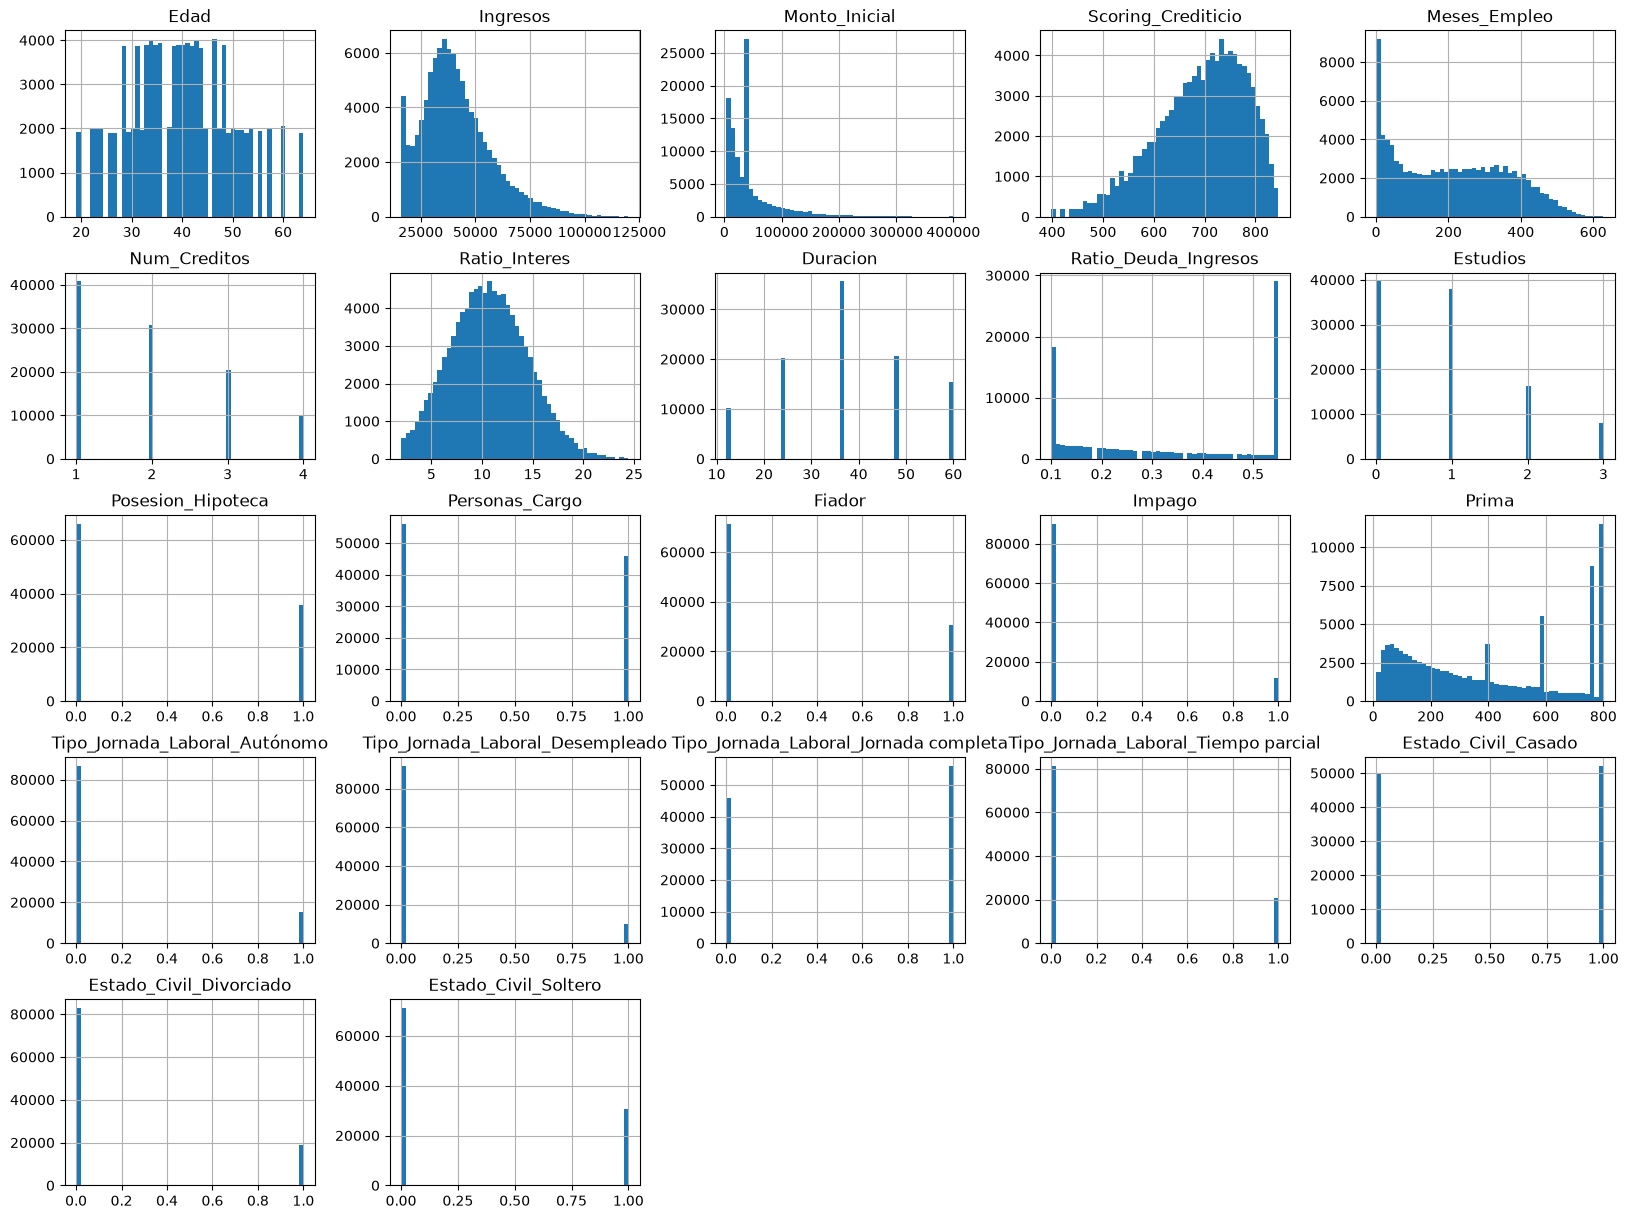

In [78]:
df_filtrado.hist(bins = 50, figsize = (20,15))
plt.show()